# Trenowanie i ocena modeli

W tej części projektu przygotowano trzy modele klasyfikacyjne:
- Logistic Regression — model z natury wyjaśnialny,
- Random Forest — model złożony,
- Gradient Boosting — model złożony.

Celem jest porównanie jakości modeli w zadaniu klasyfikacji ryzyka cukrzycy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/diabetes.csv")

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768,)


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

In [4]:
zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

for col in zero_columns:
    X_train_clean[col] = X_train_clean[col].replace(0, np.nan)
    X_test_clean[col] = X_test_clean[col].replace(0, np.nan)
    

Wartości 0 w wybranych kolumnach potraktowano jako braki danych, ponieważ dla cech takich jak poziom glukozy, BMI, ciśnienie krwi, grubość fałdu skórnego i insulina wartość 0 nie jest realistyczna medycznie. Braki danych zostaną uzupełnione medianą w pipeline'ach modeli.

## Model 1: Logistic Regression

In [5]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline_logistic = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=500))
])

pipeline_logistic.fit(X_train_clean, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

In [35]:
y_pred_logistic = pipeline_logistic.predict(X_test_clean)

## Accuracy

In [28]:
from sklearn.metrics import accuracy_score

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

accuracy_logistic

0.7077922077922078

## Confusion matrix

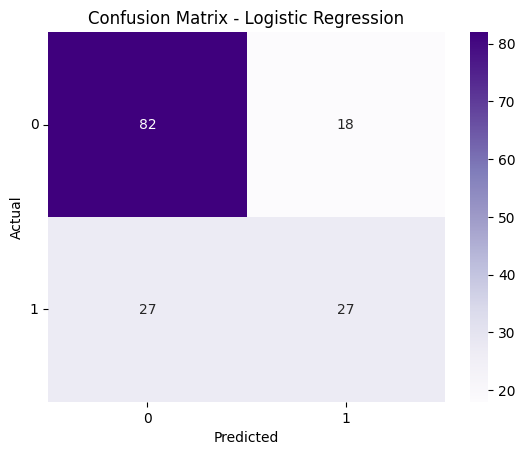

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_logistic)

sns.heatmap(
    pd.DataFrame(cm),
    annot=True,       # liczby w komórkach
    fmt='d',          # format liczb (integer)
    cmap='Purples'
)

plt.yticks(rotation=0)   # etykiety osi Y pionowo
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

## Classification report

In [10]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.75      0.82      0.78       100
           1       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



## ROC curve

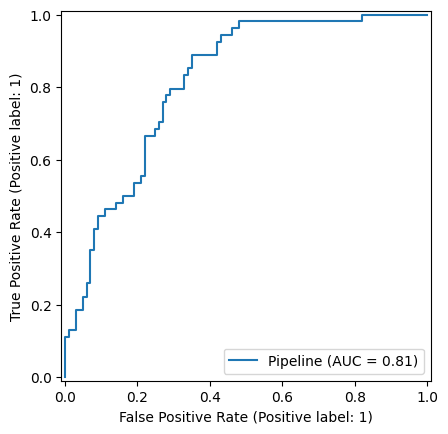

In [31]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

roc_auc_logistic = roc_auc_score(y_test, pipeline.predict_proba(X_test_clean)[:, 1])
RocCurveDisplay.from_estimator(pipeline, X_test, y_test)
plt.show()

## Model 2: Random Forest

In [12]:
from sklearn.tree import DecisionTreeClassifier

In [13]:
tree = DecisionTreeClassifier(max_depth=3)
tree.fit(X_train_clean, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

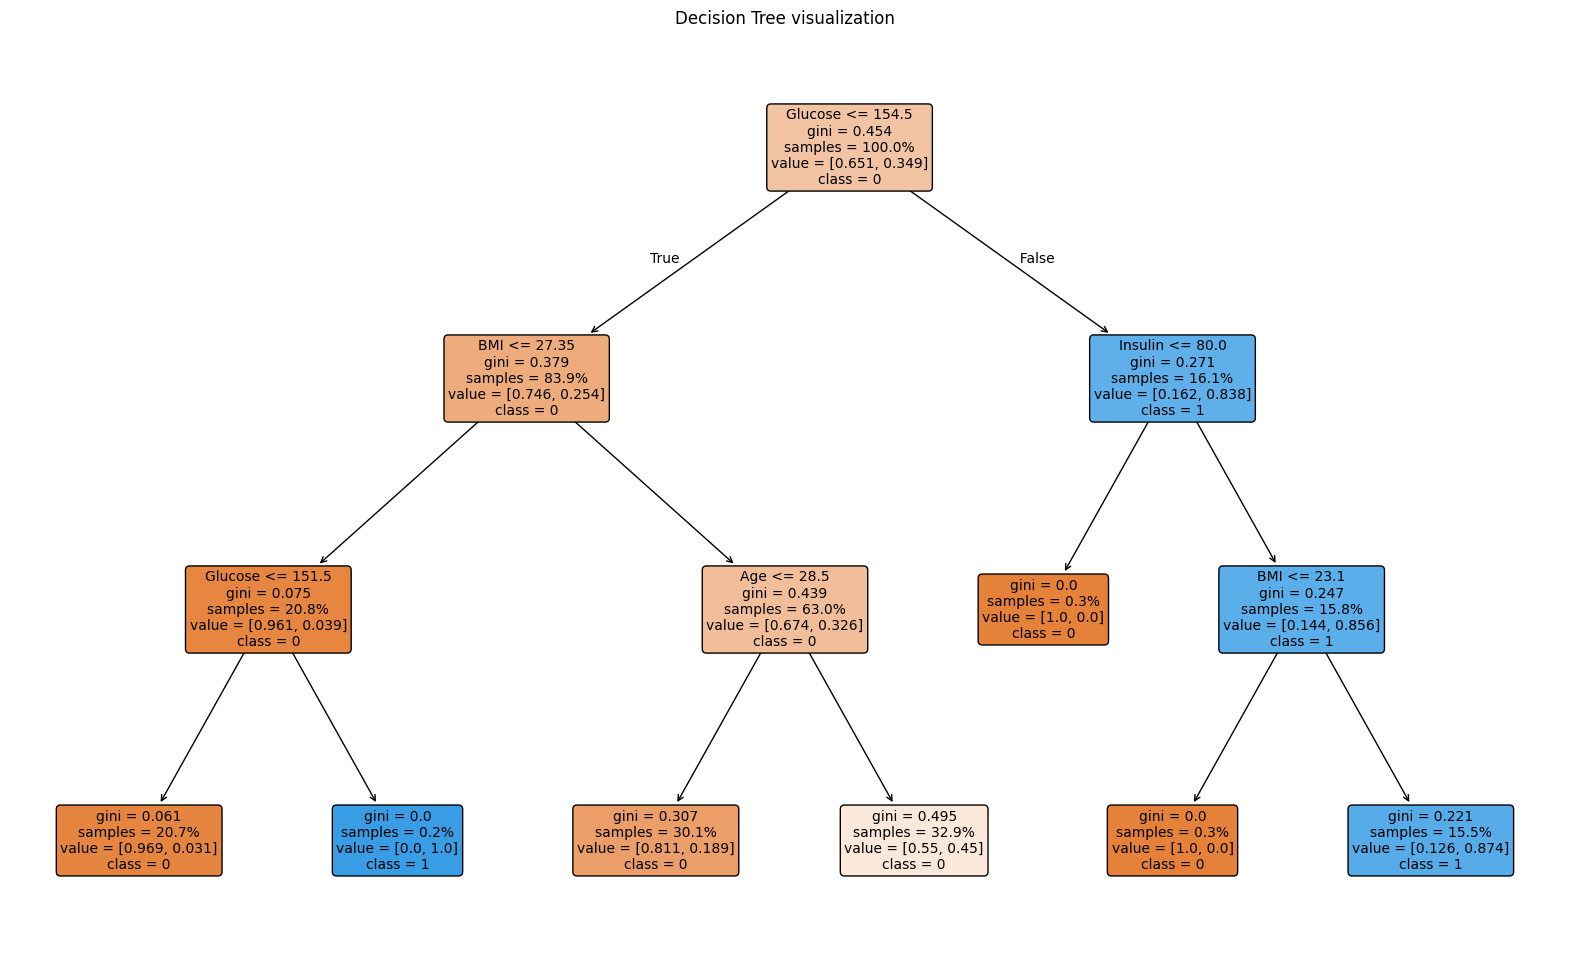

In [14]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 12))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["0", "1"],
    filled=True,
    fontsize=10,
    rounded=True,
    proportion=True
)

plt.title("Decision Tree visualization")
plt.show()

Model jako pierwszą cechę wykorzystał poziom glukozy (`Glucose`), co sugeruje, że jest ona jedną z najważniejszych zmiennych przy przewidywaniu cukrzycy. Dla niższych wartości glukozy model częściej przewiduje klasę 0, czyli brak cukrzycy, natomiast dla wyższych wartości częściej przechodzi do gałęzi prowadzących do klasy 1. 

In [15]:
## Model 2: Random Forest

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

In [17]:
pipeline_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ))
])

pipeline_rf.fit(X_train_clean, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fe

In [18]:
y_pred_rf = pipeline_rf.predict(X_test_clean)

## Accuracy

In [19]:
from sklearn.metrics import accuracy_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)

accuracy_rf

0.7402597402597403

## Confusion matrix

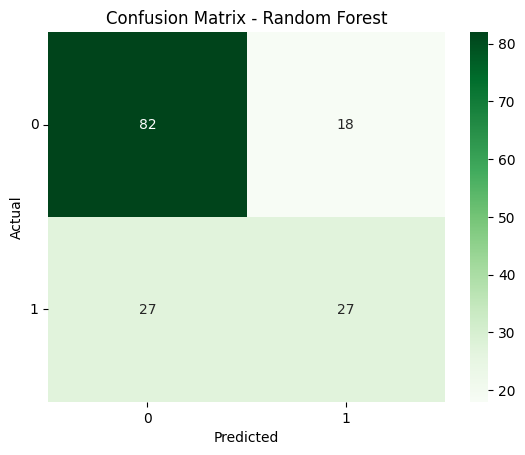

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(
    pd.DataFrame(cm),
    annot=True,       # liczby w komórkach
    fmt='d',          # format liczb (integer)
    cmap='Greens'
)

plt.yticks(rotation=0)   # etykiety osi Y pionowo
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

## Classification report

In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.78      0.84      0.81       100
           1       0.65      0.56      0.60        54

    accuracy                           0.74       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.74      0.73       154



In [22]:
## ROC AUC

ROC AUC: 0.8167592592592593


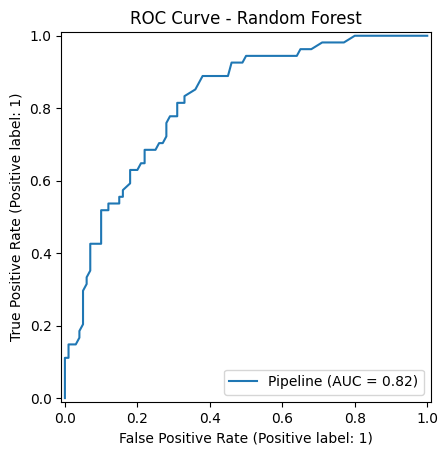

In [23]:
y_proba_rf = pipeline_rf.predict_proba(X_test_clean)[:, 1]

roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print("ROC AUC:", roc_auc_rf)

RocCurveDisplay.from_estimator(
    pipeline_rf,
    X_test_clean,
    y_test
)

plt.title("ROC Curve - Random Forest")
plt.show()

## Model 3: Support Vector Classifier

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

pipeline_svc = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear", probability=True))
])

pipeline_svc.fit(X_train_clean, y_train)

print("SVC trained.")

SVC trained.


In [25]:
y_pred_svc = pipeline_svc.predict(X_test_clean)

In [26]:
from sklearn.metrics import accuracy_score

accuracy_svc = accuracy_score(y_test, y_pred_svc)
accuracy_svc

0.7012987012987013

ROC AUC: 0.8132407407407408


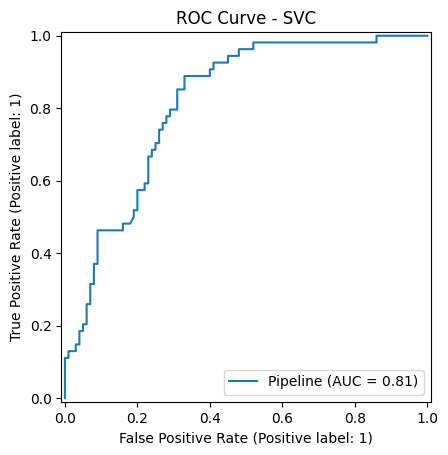

In [27]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt

y_proba_svc = pipeline_svc.predict_proba(X_test_clean)[:, 1]

roc_auc_svc = roc_auc_score(y_test, y_proba_svc)

print("ROC AUC:", roc_auc_svc)

RocCurveDisplay.from_estimator(
    pipeline_svc,
    X_test_clean,
    y_test
)

plt.title("ROC Curve - SVC")
plt.show()

In [32]:
results_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_logistic,
        "ROC AUC": roc_auc_logistic
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_rf,
        "ROC AUC": roc_auc_rf
    },
    {
        "Model": "SVC",
        "Accuracy": accuracy_svc,
        "ROC AUC": roc_auc_svc
    }
])

results_df

,Model,Accuracy,ROC AUC
0,Logistic Regression,0.707792,0.812963
1,Random Forest,0.740260,0.816759
2,SVC,0.701299,0.813241


In [36]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, y_pred_logistic),
        "Balanced accuracy": balanced_accuracy_score(y_test, y_pred_logistic),
        "Precision": precision_score(y_test, y_pred_logistic),
        "Recall": recall_score(y_test, y_pred_logistic),
        "F1": f1_score(y_test, y_pred_logistic),
        "ROC AUC": roc_auc_score(
            y_test,
            pipeline_logistic.predict_proba(X_test_clean)[:, 1]
        )
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Balanced accuracy": balanced_accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1": f1_score(y_test, y_pred_rf),
        "ROC AUC": roc_auc_score(
            y_test,
            pipeline_rf.predict_proba(X_test_clean)[:, 1]
        )
    },
    {
        "Model": "SVC",
        "Accuracy": accuracy_score(y_test, y_pred_svc),
        "Balanced accuracy": balanced_accuracy_score(y_test, y_pred_svc),
        "Precision": precision_score(y_test, y_pred_svc),
        "Recall": recall_score(y_test, y_pred_svc),
        "F1": f1_score(y_test, y_pred_svc),
        "ROC AUC": roc_auc_score(
            y_test,
            pipeline_svc.predict_proba(X_test_clean)[:, 1]
        )
    }
])

results_df

,Model,Accuracy,Balanced accuracy,Precision,Recall,F1,ROC AUC
0,Logistic Regression,0.707792,0.660000,0.600000,0.500000,0.545455,0.812963
1,Random Forest,0.740260,0.697778,0.652174,0.555556,0.600000,0.816759
2,SVC,0.701299,0.650741,0.590909,0.481481,0.530612,0.813241


Najlepsze wyniki w większości metryk uzyskał model Random Forest. Osiągnął najwyższą wartość accuracy, balanced accuracy, recall, F1-score oraz ROC AUC. Oznacza to, że spośród porównywanych modeli najlepiej radził sobie z klasyfikacją przypadków cukrzycy.

Wartości ROC AUC dla wszystkich modeli są jednak zbliżone i wynoszą około 0.81, co oznacza, że każdy z modeli ma umiarkowanie dobrą zdolność rozróżniania osób z cukrzycą i bez cukrzycy. Wyniki nie są idealne, dlatego modele należy traktować jako narzędzia edukacyjne, a nie diagnostyczne.

In [ ]:
## Walidacja krzyżowa


Stratified K-Fold (StratifiedKFold)
Zachowuje proporcje klas w każdym foldzie.
Zastosowanie: klasyfikacja z nierównymi klasami (imbalanced).
Bo mamy klasy 0 i 1 w nierównych proporcjach, więc chcemy, żeby w każdym foldzie była podobna proporcja osób z cukrzycą i bez cukrzycy.

In [37]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

cv_models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]),

    "SVC": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="linear", probability=True))
    ])
}

In [39]:
X_cv_clean = X.copy()

zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in zero_columns:
    X_cv_clean[col] = X_cv_clean[col].replace(0, np.nan)

In [40]:
cv_results = []

for name, model in cv_models.items():
    scores = cross_val_score(
        model,
        X_cv_clean,
        y,
        cv=cv,
        scoring="roc_auc"
    )
    
    cv_results.append({
        "Model": name,
        "ROC AUC scores": scores,
        "Mean ROC AUC": scores.mean(),
        "Std ROC AUC": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,Model,ROC AUC scores,Mean ROC AUC,Std ROC AUC
0,Logistic Regression,"[0.825, 0.8672222222222222, 0.8514814814814815...",0.836552,0.020325
1,Random Forest,"[0.8451851851851852, 0.8349074074074074, 0.840...",0.825563,0.020591
2,SVC,"[0.83, 0.8655555555555556, 0.8512962962962963,...",0.837068,0.018735


Wyniki walidacji krzyżowej pokazują, że wszystkie trzy modele osiągnęły zbliżone wartości średniego ROC AUC. Najwyższą wartość uzyskał model SVC, jednak różnica względem regresji logistycznej jest bardzo mała. Random Forest uzyskał nieco niższy średni wynik ROC AUC, mimo że na pojedynczym podziale train/test osiągnął najlepsze accuracy.

Odchylenia standardowe są niskie, co oznacza, że modele uzyskiwały dość stabilne wyniki na różnych podziałach danych. Walidacja krzyżowa pokazuje więc, że pojedynczy podział train/test może dawać nieco inny obraz jakości modeli niż ocena uśredniona z kilku podziałów.

## Podsumowanie

W tej części projektu wytrenowano i oceniono trzy modele klasyfikacyjne: Logistic Regression, Random Forest oraz SVC. Na pojedynczym podziale train/test najlepszy wynik w większości metryk uzyskał model Random Forest. Osiągnął najwyższe accuracy, balanced accuracy, recall, F1-score oraz ROC AUC.

Walidacja krzyżowa pokazała jednak, że różnice między modelami są niewielkie, a średnie wartości ROC AUC są zbliżone. Oznacza to, że wszystkie modele mają podobną zdolność rozróżniania osób z cukrzycą i bez cukrzycy.

W dalszej części projektu przeprowadzona zostanie analiza wyjaśnialności modeli z wykorzystaniem metod XAI.